In [1]:
import os
import glob
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr
from adjustText import adjust_text
from tqdm import tqdm
import time
from collections import Counter
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
import textwrap
import re
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 
import warnings
import networkx as nx

from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.patheffects as pe
from collections import defaultdict

import rmm
import cupy
import cudf
import cupy as cp
import cvxpy as cpv
from sklearn.manifold import MDS
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
from sklearn.feature_extraction.text import CountVectorizer
from cuml.linear_model import ElasticNet
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

# Load data

In [16]:
start = time.perf_counter()

path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_merged_gene_data.h5ad"

adata = sc.read_h5ad(path)

sc.logging.print_memory_usage() 
print(f"Total time: {time.perf_counter() - start:.2f} seconds")


### Remove siPRRX1 cells with non-zero MYOD1 expression
adata.X = adata.layers['raw_counts']

# Extract MYOD1 expression as a dense 1D array
myod1_expr = adata[:, 'MYOD1'].X.toarray().flatten()

# Create a mask for siPRRX1 cells with non-zero MYOD1 expression 
mask = (adata.obs['pooled_condition'] == 'siPRRX1') & (myod1_expr > 0)

cells_to_keep = ~(mask)

init_cells = adata.n_obs

adata = adata[cells_to_keep]

final_cells = adata.n_obs

print(f"Removed {init_cells - final_cells} siPRRX1 cells with non-zero MYOD1 expression.\n")

adata

Memory usage: current 10.00 GB, difference +3.57 GB
Total time: 3.05 seconds
Removed 252 siPRRX1 cells with non-zero MYOD1 expression.



View of AnnData object with n_obs × n_vars = 16115 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'high

# Score cell cycle genes

In [17]:
%%time
regev_genes = [x.strip() for x in open('../resources/regev_lab_cell_cycle_genes.txt')]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs.head()

/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(


CPU times: user 2.07 s, sys: 2.92 s, total: 4.99 s
Wall time: 5.07 s


,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,outlier,mt_outlier,leiden,cluster_str,S_score,G2M_score,phase
AAACCAAAGCAACTGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,2957.0,7.992269,15.716183,False,False,0,C1,-0.805759,5.095872,G2M
AAACCAAAGTAGGGCA_hybrid,14.0,1.0,1.0,MYOD,16.0,0.875000,NaN,NaN,NaN,Hybrid,...,1465.0,7.290293,15.135860,False,False,0,C1,0.380620,0.215486,S
AAACCAAAGTCTAGGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,3957.0,8.283494,13.937025,False,False,1,C2,-1.353488,-1.410275,G1
AAACCATTCACGTAAT_hybrid,2.0,19.0,2.0,PRRX1,23.0,0.826087,NaN,NaN,NaN,Hybrid,...,1422.0,7.260523,14.684015,False,False,3,C4,0.183167,2.922795,G2M
AAACCATTCAGGCAGA_hybrid,0.0,22.0,0.0,PRRX1,22.0,1.000000,NaN,NaN,NaN,Hybrid,...,3231.0,8.080856,17.547386,False,False,3,C4,-0.522924,4.639860,G2M


# Gene filtering

In [18]:
adata.X = adata.layers['raw_counts'].copy()

X = adata.X

if sp.issparse(X):
    # replace NaNs in the nonzero entries
    X.data = np.nan_to_num(X.data, nan=0)
    adata.X = X
else:
    # dense array
    adata.X = np.nan_to_num(X, nan=0)

# adata.X = adata.X.astype(int)
print(f"{adata.X.shape=}")
print(f"{type(adata.X)=}")

adata

adata.X.shape=(16115, 25126)
type(adata.X)=<class 'scipy.sparse._csr.csr_matrix'>


AnnData object with n_obs × n_vars = 16115 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

In [19]:
gdf = adata.var[['gene_type']].copy()
gdf = gdf.reset_index(names='names')

protein_coding = gdf[gdf['gene_type'] == 'protein_coding']['names'].unique()
print(len(protein_coding))

15822


In [9]:
rsc.get.anndata_to_CPU(adata)

In [20]:
rsc.get.anndata_to_GPU(adata)

adata.var['filter_pass'] = True # set the gene filter

# pt genes only
adata.var['filter_pass'] = np.where(~adata.var.index.isin(protein_coding), False, adata.var['filter_pass'])

# disallow GO cell cycle genes
fpath = "../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# disallow Regev cell cycle genes
fpath = "../resources/regev_lab_cell_cycle_genes.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

rsc.get.anndata_to_CPU(adata)

print(adata.var['filter_pass'].value_counts().to_string())

filter_pass
True     15393
False     9733


# SCVI

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-bffcf947-2035-5281-9af9-cb80e2ba802c]
SLURM auto-requeueing enabled. Setting signal handlers.


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 5 records. Best score: 1658.078. Signaling Trainer to stop.


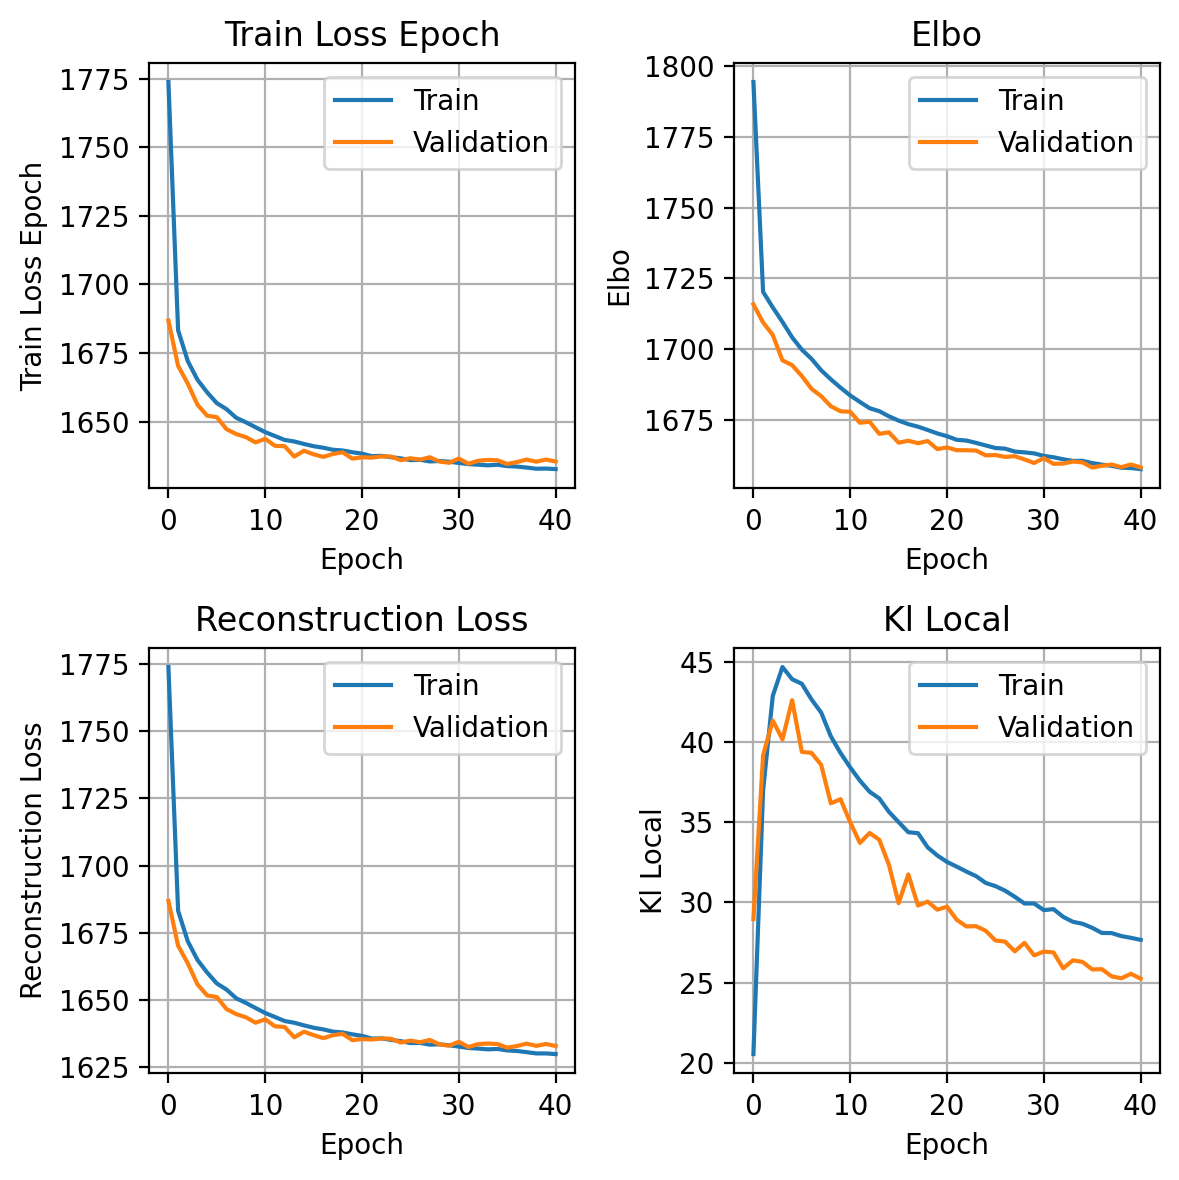

CPU times: user 3min 20s, sys: 3.11 s, total: 3min 24s
Wall time: 3min 26s


In [31]:
%%time
batch_key = "dataset"

rsc.get.anndata_to_CPU(adata)
bdata = adata.copy()
bdata = bdata[:, bdata.var['filter_pass']].copy()

rsc.get.anndata_to_GPU(bdata)
rsc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    n_top_genes=2500, # If only doing embedding, can lower this; if wanting to quantify gene expression, need to increase this number
    batch_key=batch_key,
)

bdata = bdata[:, bdata.var['highly_variable']].copy()
rsc.get.anndata_to_CPU(bdata)

# scvi
scvi.model.SCVI.setup_anndata(
    bdata, 
    batch_key=batch_key,
    continuous_covariate_keys=['S_score', 'G2M_score'],
)

model = scvi.model.SCVI(
    bdata,
    n_hidden=128,
    n_latent=10, # size of latent space we're learning; too small might not be able to capture biological differences; too large might be overfitting (good between 10-36; aim for 10-15 for MYOD data)
    n_layers=2, 
    dropout_rate=0.25, # really impacts curves below
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model.train(
    max_epochs=500,
    accelerator='gpu',
    early_stopping_patience=5, # go until we reach 5 consecutive steps without learning anything new
    early_stopping=True,
    batch_size=25,
    train_size=0.9,
    plan_kwargs={"lr": 1e-3}, # learning rate -- small is careful/cautiously forward; large is wrecklessly forward, can get stuck in local minimum (good values e-2 to e-6)
)

history = model.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# embedding

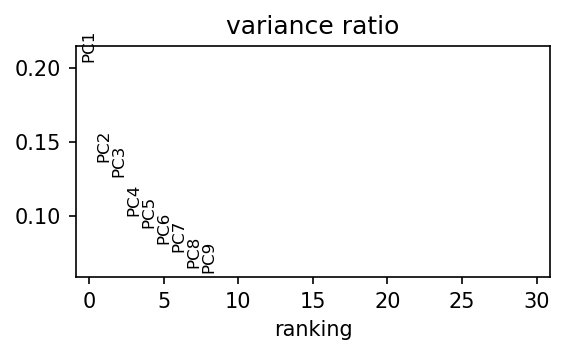

CPU times: user 276 ms, sys: 20.8 ms, total: 297 ms
Wall time: 310 ms


In [32]:
%%time 

embed = model.get_latent_representation()
embed = sc.AnnData(embed, obs=adata.obs)

rsc.get.anndata_to_GPU(embed)
rsc.pp.pca(embed)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2
sc.pl.pca_variance_ratio(embed)

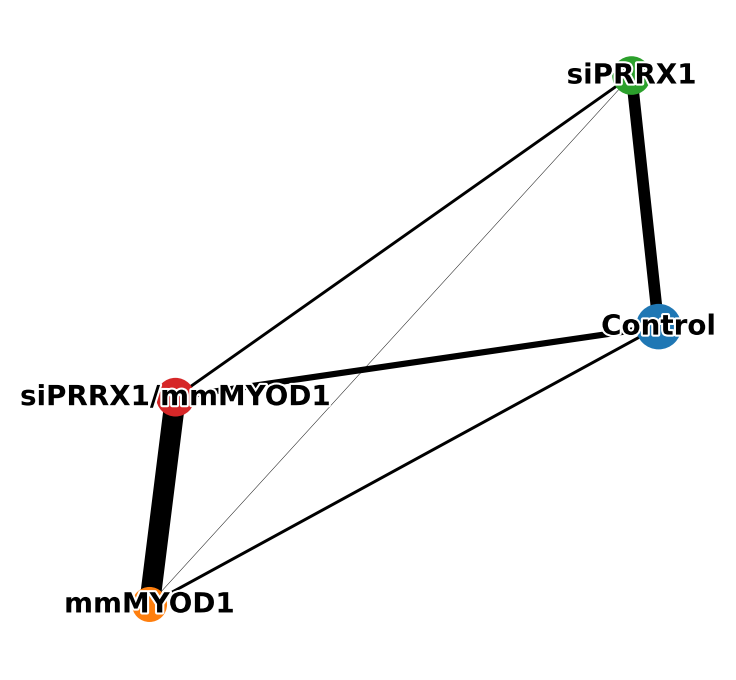

CPU times: user 216 ms, sys: 22.9 ms, total: 239 ms
Wall time: 245 ms


AnnData object with n_obs × n_vars = 16115 × 10
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    uns: 'pca', 'neighbors', 'paga', 'pooled_condition_sizes', 'pooled_condition_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [33]:
%%time
n_neighbors = 15
n_pcs = 50
paga_group_column='pooled_condition'

rsc.pp.neighbors(
    embed, 
    n_pcs=n_pcs, 
    n_neighbors=n_neighbors,
)

# plot the embedding
sc.tl.paga(embed, groups=paga_group_column)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4
sc.pl.paga(
    embed, 
    fontoutline=1.5, 
    frameon=False,          
)

embed

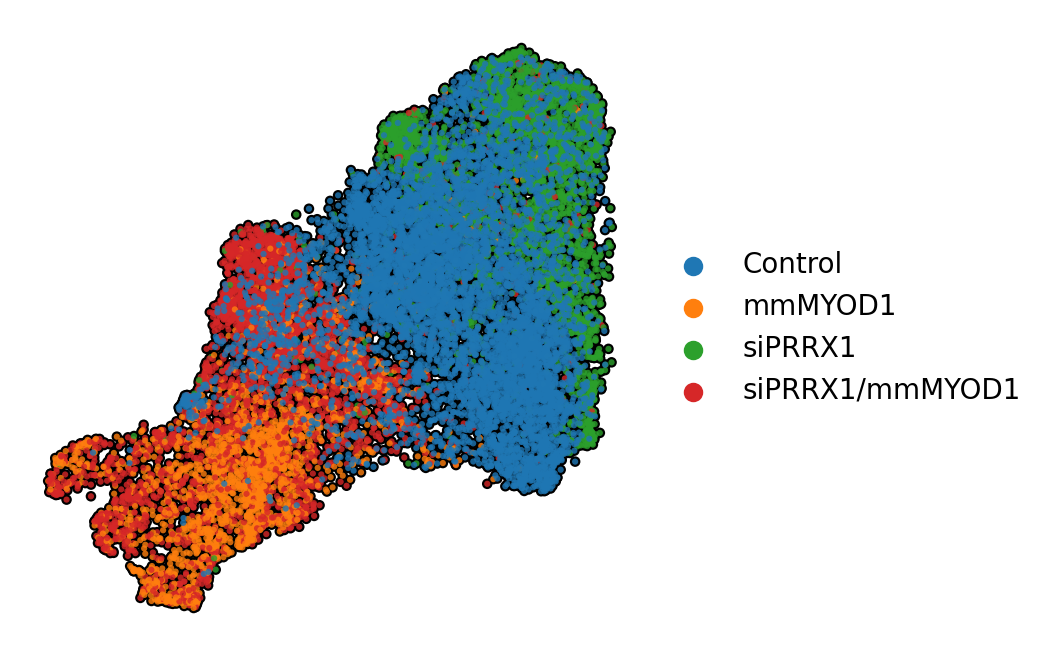

In [34]:
sc.tl.umap(
    embed,
    init_pos='paga',
    min_dist=0.2,
    # spread=5,
)

sc.pl.umap(
    embed,
    color='pooled_condition',
    size=20,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    alpha=0.8,
    title="",
    # palette=
    # palette=cluster_colors,
    #legend_loc='none',
)

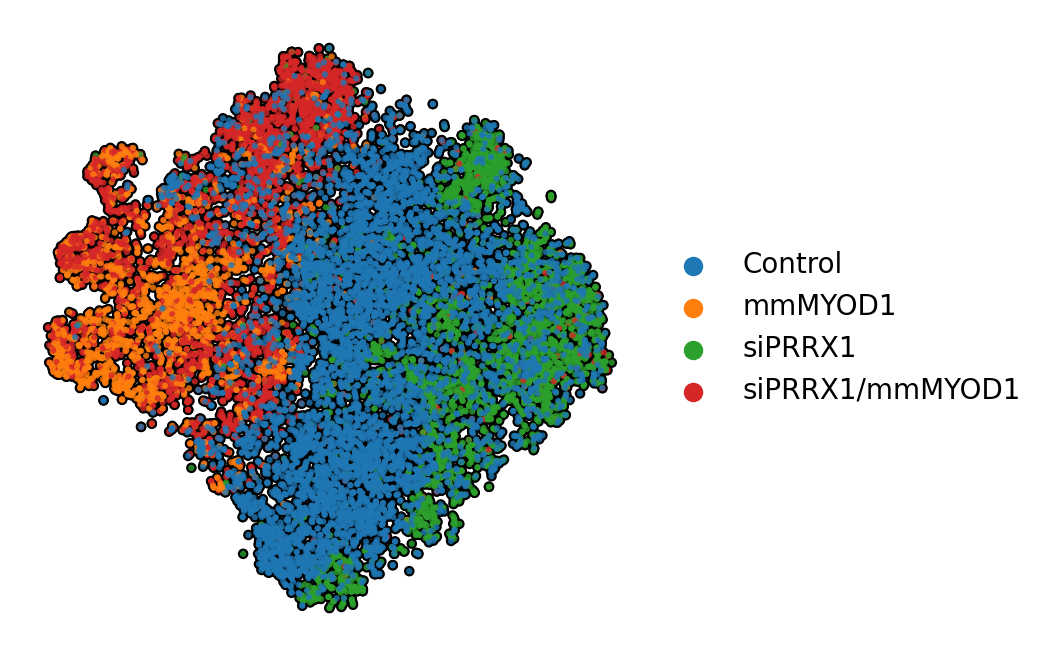

In [37]:
# rsc.get.anndata_to_CPU(embed)
# rsc.get.anndata_to_GPU(embed)

sc.tl.tsne(
    embed,
)

# rsc.get.anndata_to_CPU(embed)

sc.pl.tsne(
    embed,
    color='pooled_condition',
    size=20,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    alpha=0.8,
    title="",
)